### classifier, torch

In [1]:
%pip install --quiet torch datasets nltk tqdm matplotlib kagglehub ipywidgets numpy pandas

import numpy as np
import torch
from datasets import load_dataset
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import clear_output


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")

print("Path to dataset files:", path)

Path to dataset files: /Users/ant.korneev/.cache/kagglehub/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/versions/1


In [3]:
with open(path + '/IMDB Dataset.csv', "r") as file:
    content = file.read()

In [4]:
df = pd.read_csv(path + '/IMDB Dataset.csv', sep=',', header=None)
ds = df.to_numpy()
ds = ds[1:]

len(ds)

50000

In [5]:
import nltk

tokenizer = nltk.tokenize.WordPunctTokenizer()

train = [tokenizer.tokenize(pair[0].lower()) for pair in ds[:25000]]
val = [tokenizer.tokenize(pair[0].lower()) for pair in ds[25000:]]

In [6]:
train_labels = [0 if pair[1] == 'negative' else 1 for pair in ds[:25000]]
val_labels = [0 if pair[1] == 'negative' else 1 for pair in ds[25000:]]

In [7]:
PAD_TOKEN = '<pad>'

train_seq_len = 0
for t in train:
    if len(t) > train_seq_len:
        train_seq_len = len(t)

train = [text + [PAD_TOKEN] * (train_seq_len - len(text)) for text in train]

val_seq_len = 0
for t in val:
    if len(t) > val_seq_len:
        val_seq_len = len(t)

val = [text + [PAD_TOKEN] * (val_seq_len - len(text)) for text in val]

In [8]:
vocab_set = set()
for t in train:
    for w in t:
        vocab_set.add(w)
        
for t in val:
    for w in t:
        vocab_set.add(w)

In [9]:
vocab_i_map = {}
i_vocab_map = {}
for i, token in enumerate(vocab_set):
    vocab_i_map[token] = i
    i_vocab_map[i] = token

In [10]:
for i, text in enumerate(train):
    for j, token in enumerate(text):
        train[i][j] = vocab_i_map[token]
        
for i, text in enumerate(val):
    for j, token in enumerate(text):
        val[i][j] = vocab_i_map[token]

KeyboardInterrupt: 

In [ ]:
# print(val[1])
# [i_vocab_map[i] for i in val[1]]

In [ ]:
vocab_size = len(vocab_set)
emb_dim = 64
hid_size = 1024

In [ ]:
class Cls(torch.nn.Module):
    def __init__(self):
        super().__init__()
        
        self.embs = torch.nn.Embedding(vocab_size, emb_dim)
        
        self.lstm = torch.nn.LSTM(emb_dim, hid_size, 4)
        
        self.norm = torch.nn.LayerNorm(hid_size)
        self.dropout = torch.nn.Dropout(p=0.2)
        
        self.fc1 = torch.nn.Linear(hid_size, hid_size)
        self.activation1 = torch.nn.ReLU()
        
        self.fc2 = torch.nn.Linear(hid_size, 1)
        self.activation2 = torch.nn.Sigmoid()
        
        
        
    # X: [batch_size, seq_len]
    def forward(self, X):
        X = self.embs(X) # [batch_size, seq_len, emb_dim]
        
        X, (hn, cn) = self.lstm(X)
        
        X = self.norm(X)
        X = self.dropout(X)
        
        X = self.fc1(X) # [batch_size, seq_len, hid_size]
        X = self.activation1(X)
        
        X = self.fc2(X) # [batch_size, seq_len, 2]
        X = self.activation2(X)
    
        return X


In [ ]:
dummy_batch = torch.tensor(train[:2])

In [ ]:
model = Cls()

In [ ]:
# model.forward(dummy_batch)

In [ ]:
opt = torch.optim.Adam(model.parameters())

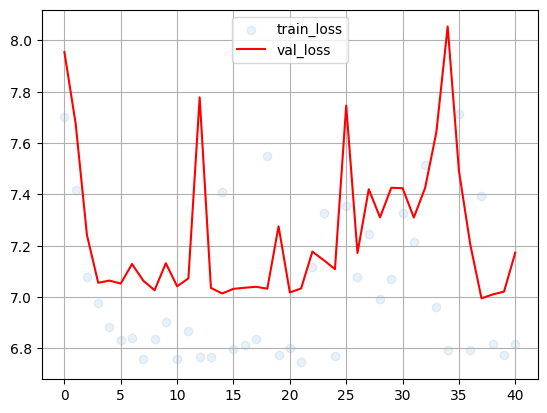

  3%|▎         | 44/1562 [08:27<4:59:06, 11.82s/it]

In [ ]:
batch_size = 16

train_loss = []
val_loss = []

for i in tqdm(range(0, len(train), batch_size), total=len(train) // batch_size):
    if i + batch_size > len(train):
        break
    
    batch = train[i : i + batch_size]
    batch = torch.tensor(batch)
    val_batch = val[i : i + batch_size]
    val_batch = torch.tensor(val_batch)
    
    batch_labels = train_labels[i : i + batch_size]
    batch_labels = torch.tensor(batch_labels)
    val_batch_labels = val_labels[i : i + batch_size]
    val_batch_labels = torch.tensor(val_batch_labels)
    
    preds = model.forward(batch)
    preds = preds.squeeze(dim=2)
    val_preds = model.forward(val_batch)
    val_preds = val_preds.squeeze(dim=2)
    
    batch_train_loss = torch.nn.functional.cross_entropy(preds, batch_labels)
    train_loss.append(batch_train_loss.detach().numpy())
    batch_val_loss = torch.nn.functional.cross_entropy(val_preds, val_batch_labels)
    val_loss.append(batch_val_loss.detach().numpy())
    
    batch_train_loss.backward()
    opt.step()
    opt.zero_grad()
    
    if i % 10 == 0:
        clear_output(True)
        plt.scatter(range(len(train_loss)), train_loss, alpha=0.1, label='train_loss')
        if len(val_loss):
            plt.plot(range(len(val_loss)), val_loss, color='red', label='val_loss')
        plt.legend(); plt.grid(); plt.show()
    

In [ ]:
train_loss, len(train_loss), range(len(train_loss))

([array(6.772377, dtype=float32)], 1, range(0, 1))

<Figure size 640x480 with 0 Axes>

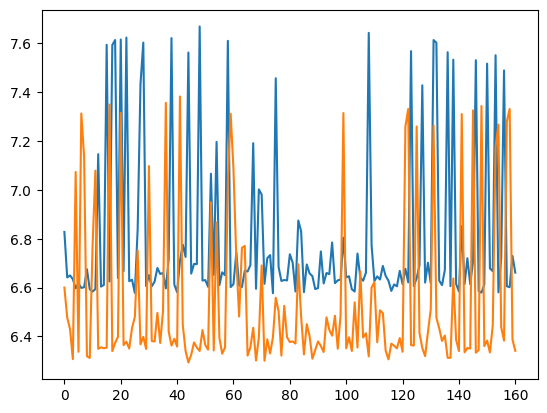

In [ ]:
plt.clf()
fig, ax = plt.subplots()
ax.plot(train_loss)
ax.plot(val_loss)

In [ ]:
# TODO: predict with trained